# Beschreibung: trajectories.ipynb

Kurz: Dieses Notebook berechnet und visualisiert mittlere Woody-Cover‑Trajektorien relativ zu Brandereignissen.  
Es nutzt ein Multi‑Band‑Raster, in dem die ersten Bänder annualisierte Woody‑Cover‑Werte (z. B. 1985–2025) und die folgenden Bänder jährliche Burn‑Flags (z. B. 2000–2025) enthalten.

Funktionen / Ablaufschritte
- Raster laden (woody + burned), NoData berücksichtigen
- Pixel mit genau 1 Brandereignis identifizieren
- Für diese Pixel das Brandjahr bestimmen (Index)
- Mittlere Trajektorie über ein Fenster von -5 bis +5 Jahren um das Brandjahr berechnen
- Plot der mittleren Trajektorie
- Erweiterte Analysen:
  - Gruppentrajektorien (z. B. frühe vs. späte Brände)
  - Stratifizierung nach Anzahl Brandereignisse (1x, ≥2x, …)
  - Optionale Funktionen für Mehrfachbrände (erstes Brandjahr als Referenz)

Eingaben (anpassen)
- raster_path: Pfad zur Datei `woody_burned_combined.tif`
- years_woody / years_burned: Jahreslisten, passend zu den Bändern im Raster
- nodata: wird aus dem Raster übernommen

Ausgaben
- Variablen: `traj_list`, `early_traj`, `late_traj`, Masken (`single_fire_mask`, …)
- Grafiken: Trajektorienplots, Histogramme, Panelplots

Wichtig / Hinweise
- Genügend RAM nötig, da ganze Bänder in den Speicher geladen werden.
- NoData‑Werte werden in Berechnungen zu NaN konvertiert.
- Mindestanzahl Pixel (z. B. 50) schützt vor instabilen Mittelwerten — Parameter anpassen je nach Stratum-Größe.
- Für Stratifizierung nach Biome/Ökoregionen empfiehlt sich ein rasterisiertes Stratum‑Layer (pixelaligniert mit dem Woody/Burned‑Raster).

Benötigte Pakete
- rasterio, numpy, matplotlib, (optional) pandas, geopandas für weitergehende Stratifizierung

Kurzbefehle / Tipps
- Für andere relative Fenster: ersetze `range(-5, 6)` durch gewünschten Bereich.
- Für Stratifizierung: lade ein Ecoregions‑Raster und verwende eine Funktion wie `calc_stratified_trajectory(...)`.

Beispiel-Aufruf (Zellen nacheinander ausführen)
1. Pfade und Jahreslisten prüfen
2. Cell "Lade Rasterdaten ..." ausführen
3. Berechnung und Plot-Cells ausführen

Ziel: schnelle, reproduzierbare Analyse von Vegetations‑Recovery nach Feuerereignissen und einfache Erweiterung zu gruppen- bzw. stratum‑basierten

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import time

raster_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\02_Trajectories_Full\woody_burned_combined.tif"
years_woody = list(range(1985, 2025+1))   # 40 Jahre
years_burned = list(range(2000, 2025+1))  # 26 Jahre


In [3]:

print("Lade Rasterdaten ...")
start = time.time()
with rasterio.open(raster_path) as src:
    woody = src.read(range(1, len(years_woody)+1))
    burned = src.read(range(len(years_woody)+1, src.count+1))  # bis zur letzten Bandnummer
    nodata = src.nodata
print(f"Rasterdaten geladen. Dauer: {time.time() - start:.2f} Sekunden")
print(f"Woody Shape: {woody.shape}, Burned Shape: {burned.shape}")

print("Finde Pixel mit genau 1 Burn Event ...")
start = time.time()
burned_sum = np.sum(burned == 1, axis=0)  # (y, x)
single_fire_mask = burned_sum == 1
print(f"Pixel mit genau 1 Feuer: {np.sum(single_fire_mask)}")
print(f"Dauer: {time.time() - start:.2f} Sekunden")

print("Ermittle Brandjahr für diese Pixel ...")
start = time.time()
burned_year_idx = np.argmax(burned == 1, axis=0)  # (y, x)
print(f"Dauer: {time.time() - start:.2f} Sekunden")

print("Berechne durchschnittliche Trajektorien ...")
start = time.time()
traj_list = []
for rel_year in range(-5, 6):  # -5 bis +5
    woody_band = burned_year_idx + rel_year + (years_burned[0] - years_woody[0])
    valid_mask = (
        (woody_band >= 0) &
        (woody_band < len(years_woody)) &
        single_fire_mask
    )
    band_vals = np.full_like(burned_sum, np.nan, dtype=float)
    # Indizes für gültige Pixel
    y_idx, x_idx = np.where(valid_mask)
    band_vals[y_idx, x_idx] = woody[woody_band[y_idx, x_idx], y_idx, x_idx]
    band_vals[band_vals == nodata] = np.nan
    mean_val = np.nanmean(band_vals)
    traj_list.append(mean_val)
    print(f"Relatives Jahr {rel_year}: Mittelwert = {mean_val:.2f}")

print(f"Trajektorien berechnet. Dauer: {time.time() - start:.2f} Sekunden")


Lade Rasterdaten ...
Rasterdaten geladen. Dauer: 40.08 Sekunden
Woody Shape: (41, 9660, 10483), Burned Shape: (25, 9660, 10483)
Finde Pixel mit genau 1 Burn Event ...
Pixel mit genau 1 Feuer: 2579129
Dauer: 5.84 Sekunden
Ermittle Brandjahr für diese Pixel ...
Dauer: 5.79 Sekunden
Berechne durchschnittliche Trajektorien ...
Relatives Jahr -5: Mittelwert = 16.94
Relatives Jahr -4: Mittelwert = 17.18
Relatives Jahr -3: Mittelwert = 17.47
Relatives Jahr -2: Mittelwert = 17.67
Relatives Jahr -1: Mittelwert = 17.79
Relatives Jahr 0: Mittelwert = 17.73
Relatives Jahr 1: Mittelwert = 16.33
Relatives Jahr 2: Mittelwert = 15.54
Relatives Jahr 3: Mittelwert = 15.83
Relatives Jahr 4: Mittelwert = 15.85
Relatives Jahr 5: Mittelwert = 15.94
Trajektorien berechnet. Dauer: 33.51 Sekunden


Erstelle Plot ...


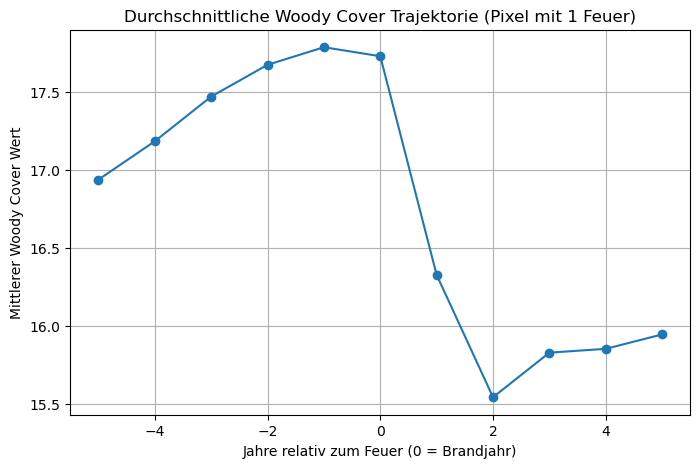

Plot erstellt. Dauer: 2.31 Sekunden


In [7]:

print("Erstelle Plot ...")
start = time.time()
plt.figure(figsize=(8,5))
plt.plot(range(-5,6), traj_list, marker='o')
plt.xlabel("Jahre relativ zum Feuer (0 = Brandjahr)")
plt.ylabel("Mittlerer Woody Cover Wert")
plt.title("Durchschnittliche Woody Cover Trajektorie (Pixel mit 1 Feuer)")
plt.grid()
plt.show()
print(f"Plot erstellt. Dauer: {time.time() - start:.2f} Sekunden")

## Ideen für weiterführende Auswertungen und Analysen:

1. Konfidenzintervall / Standardabweichung der Trajektorien

    - Zeige zusätzlich zur Mittelwert-Trajektorie die Streuung (z.B. ±1 Standardabweichung oder 95%-Konfidenzintervall) als Schattierung im Plot.

2. Vergleich nach Landnutzung, Klima- oder Vegetationszonen

    Wenn du entsprechende Masken hast: Vergleiche Trajektorien für verschiedene Regionen (z.B. Mittelmeer vs. Mitteleuropa, Wald vs. Offenland).

3. Gruppierung nach Brandjahr

    Untersuche, ob sich die Trajektorien für frühe (z.B. 2000–2010) und späte (z.B. 2011–2025) Brände unterscheiden.

4. Analyse nach Brandintensität

    Falls du Intensitätsdaten hast (z.B. Anzahl gebrannter Jahre pro Pixel): Vergleiche Trajektorien für Pixel mit 1, 2, 3, ... Feuern.

5. Recovery-Rate

    Berechne, wie viele Jahre es dauert, bis der Woody Cover wieder das Niveau von vor dem Brand erreicht (falls überhaupt).

6. Histogramme der Woody Cover Werte

    Zeige Histogramme der Woody Cover Werte für verschiedene Zeitpunkte (z.B. -1, 0, +1 Jahre relativ zum Brand).

7. Karten der Differenzwerte

    Erstelle Karten, die z.B. die Differenz Woody Cover (Jahr -1) minus (Jahr +5) für alle Pixel mit 1 Feuer zeigen.

8. Einzelpixel-Trajektorien

    Zeige exemplarisch einige Einzelpixel-Trajektorien (zufällig oder gezielt ausgewählt).

9. Anteil vollständiger Erholung

    Berechne den Anteil der Pixel, bei denen der Woody Cover nach 5 Jahren wieder mindestens das Niveau von vor dem Brand erreicht.

10. Zeit bis zum Minimum nach Brand

    Analysiere, wie viele Jahre nach dem Brand das Minimum im Woody Cover erreicht wird.

3. Vergleich der Trajectorien nach Branjahr-Gruppen

- Teile die Brandjahre in zwei Gruppen, z.B. „frühe Brände“ (2000–2011) und „späte Brände“ (2012–2024).
- Berechne für jede Gruppe die durchschnittliche Trajektorie (wie zuvor).
- Zeige beide Trajektorien nebeneinander im Panelplot.

Lade Rasterdaten ...
Rasterdaten geladen. Dauer: 27.42 Sekunden
Berechne Trajektorien für frühe Brände ...
Berechne Trajektorien für späte Brände ...
Erstelle Panelplot ...


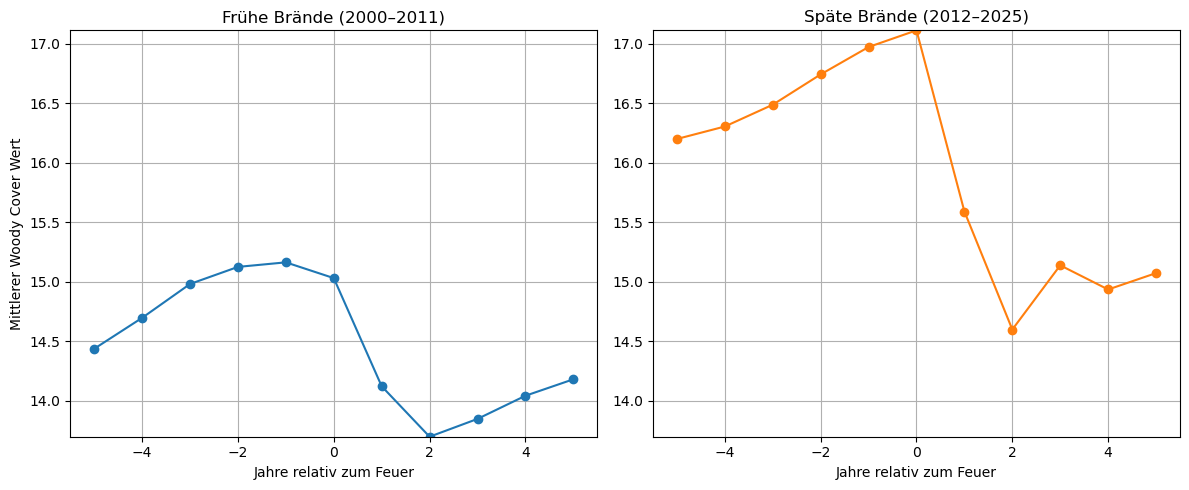

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import time

raster_path = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\02_Trajectories_Full\woody_burned_combined.tif"
years_woody = list(range(1985, 2026))   # 41 Jahre
#years_burned = list(range(2000, 2025+1))  # 26 Jahre
years_burned = list(range(2000, 2000 + burned.shape[0]))

# Gruppendefinition
early_years = [y for y in years_burned if 2000 <= y <= 2011]
late_years = [y for y in years_burned if 2012 <= y <= max(years_burned)]

print("Lade Rasterdaten ...")
start = time.time()
with rasterio.open(raster_path) as src:
    woody = src.read(range(1, len(years_woody)+1))
    burned = src.read(range(len(years_woody)+1, src.count+1))
    nodata = src.nodata
# Korrigiere years_burned auf tatsächliche Länge
years_burned = list(range(2000, 2000 + burned.shape[0]))
print(f"Rasterdaten geladen. Dauer: {time.time() - start:.2f} Sekunden")

def calc_group_traj(burned, group_years, years_woody, years_burned, woody, nodata):
    group_mask = np.zeros_like(burned[0], dtype=bool)
    group_indices = []
    for y in group_years:
        idx = years_burned.index(y)
        group_mask |= (burned[idx] == 1)
        group_indices.append(idx)
    # Pixel mit genau 1 Feuer in dieser Gruppe
    burned_sum = np.sum(burned[group_indices] == 1, axis=0)
    single_fire_mask = (burned_sum == 1)
    # Brandjahr pro Pixel
    burned_group = burned[group_indices]
    burned_year_idx = np.argmax(burned_group == 1, axis=0)
    # Map auf globalen burned_year_idx
    burned_year_idx_global = np.array(group_indices)[burned_year_idx]
    traj_list = []
    for rel_year in range(-5, 6):
        woody_band = burned_year_idx_global + rel_year + (years_burned[0] - years_woody[0])
        valid_mask = (
            (woody_band >= 0) &
            (woody_band < len(years_woody)) &
            single_fire_mask
        )
        band_vals = np.full_like(burned_sum, np.nan, dtype=float)
        y_idx, x_idx = np.where(valid_mask)
        band_vals[y_idx, x_idx] = woody[woody_band[y_idx, x_idx], y_idx, x_idx]
        band_vals[band_vals == nodata] = np.nan
        traj_list.append(np.nanmean(band_vals))
    return traj_list

print("Berechne Trajektorien für frühe Brände ...")
early_traj = calc_group_traj(burned, early_years, years_woody, years_burned, woody, nodata)
print("Berechne Trajektorien für späte Brände ...")
late_traj = calc_group_traj(burned, late_years, years_woody, years_burned, woody, nodata)

ymin = min(np.nanmin(early_traj), np.nanmin(late_traj))
ymax = max(np.nanmax(early_traj), np.nanmax(late_traj))

print("Erstelle Panelplot ...")
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(-5,6), early_traj, marker='o', color='tab:blue')
plt.title("Frühe Brände (2000–2011)")
plt.xlabel("Jahre relativ zum Feuer")
plt.ylabel("Mittlerer Woody Cover Wert")
plt.ylim(ymin, ymax)
plt.grid()

plt.subplot(1,2,2)
plt.plot(range(-5,6), late_traj, marker='o', color='tab:orange')
plt.title("Späte Brände (2012–2025)")
plt.xlabel("Jahre relativ zum Feuer")
plt.ylim(ymin, ymax)
plt.grid()

plt.tight_layout()
plt.show()